### Optimizing Time Series Forecasting: A Comparative Study of Adam and Nesterov Accelerated Gradient on LSTM and GRU networks Using Stock Market data - Experiments Code

## Step 1: Libary Imports

In [1]:
# Import necessary libraries for data
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

import yfinance as yf
from datetime import datetime

# Define the stock ticker and date range
stock_ticker = 'AAPL'
start_date = '2014-01-01'
end_date = '2024-08-01'


## Step 2: Data Preparation and Splitting


In [2]:
df = yf.download(stock_ticker, start=start_date, end=end_date, multi_level_index=False)

# Filters the 'Close' column
data = df.filter(['Close'])
data

/tmp/ipykernel_17/4001820110.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_ticker, start=start_date, end=end_date, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close
Date,
2014-01-02,17.124887
2014-01-03,16.748726
2014-01-06,16.840055
2014-01-07,16.719616
2014-01-08,16.825495
...,...
2024-07-25,215.622177
2024-07-26,216.088150
2024-07-29,216.365738


In [3]:
# Convert the dataframe to a numpy array
dataset = data.values

# Split the dataset into training, validation, and test sets
training_data_len = int(np.ceil(len(dataset) * 0.70))
validation_data_len = int(np.ceil(len(dataset) * 0.85))

train_data = dataset[:training_data_len, :]
val_data = dataset[training_data_len:validation_data_len, :]
test_data = dataset[validation_data_len:, :]

print(f"Training Data Length: {len(train_data)}")
print(f"Validation Data Length: {len(val_data)}")
print(f"Test Data Length: {len(test_data)}")


Training Data Length: 1864
Validation Data Length: 399
Test Data Length: 399


Data Scaling


In [4]:
# Scale the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train_data = scaler.fit_transform(train_data)
scaled_val_data = scaler.transform(val_data)
scaled_test_data = scaler.transform(test_data)

# Concatenate splits so validation/test windows can use prior context
full_scaled_data = np.vstack([scaled_train_data, scaled_val_data, scaled_test_data])
train_end = len(scaled_train_data)
val_end = train_end + len(scaled_val_data)

print("Data scaling completed.")


Data scaling completed.


## Sequence Construction and Sliding Window Tuning
Sequences are built from the full scaled series so validation/test windows retain context from prior splits.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, Dropout
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# training_callbacks = [
#     EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
# ]

EPOCHS = 50
BATCH_SIZE = 32

2026-07-14 08:02:39.795813: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784016160.091961      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784016160.174835      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784016160.902680      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784016160.902753      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784016160.902757      17 computation_placer.cc:177] computation placer alr

### Sliding Window Hyperparameter Tuning
We search over candidate lookback windows using a lightweight LSTM on the validation set, then lock in the best window for all model/optimizer comparisons.

In [6]:
def create_sequences(data, window_size, start_idx, end_idx):
    """Build (X, y) pairs from a contiguous scaled series slice."""
    x, y = [], []
    for i in range(start_idx + window_size, end_idx):
        x.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    x, y = np.array(x), np.array(y)
    return x.reshape(x.shape[0], x.shape[1], 1), y


def rmse_in_original_scale(y_scaled, y_pred_scaled):
    y_true = scaler.inverse_transform(y_scaled.reshape(-1, 1))
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [7]:
WINDOW_CANDIDATES = [30, 60, 90, 120]

### LSTM Adam Window Tuning

In [8]:
window_tuning_results_lstm_adam = []
best_window_size_lstm_adam = WINDOW_CANDIDATES[0]
best_window_val_rmse_lstm_adam = float('inf')

In [9]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions)
    window_tuning_results_lstm_adam.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_lstm_adam:
        best_window_val_rmse_lstm_adam = candidate_val_rmse
        best_window_size_lstm_adam = candidate_window

print(f'\nSelected sliding window: {best_window_size_lstm_adam} (validation RMSE: {best_window_val_rmse_lstm_adam:.4f})')

x_train_lstm_adam, y_train_lstm_adam = create_sequences(full_scaled_data, best_window_size_lstm_adam, 0, train_end)
x_val_lstm_adam, y_val_lstm_adam = create_sequences(full_scaled_data, best_window_size_lstm_adam, train_end, val_end)
x_test_lstm_adam, y_test_lstm_adam = create_sequences(full_scaled_data, best_window_size_lstm_adam, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_lstm_adam)}, Val samples: {len(x_val_lstm_adam)}, Test samples: {len(x_test_lstm_adam)}')


Tuning sliding window on validation RMSE...


2026-07-14 08:02:55.924699: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 24.1279


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 25.6014


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 18.1831


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 21.5031

Selected sliding window: 90 (validation RMSE: 18.1831)
Data preparation completed.
Train samples: 1774, Val samples: 309, Test samples: 309


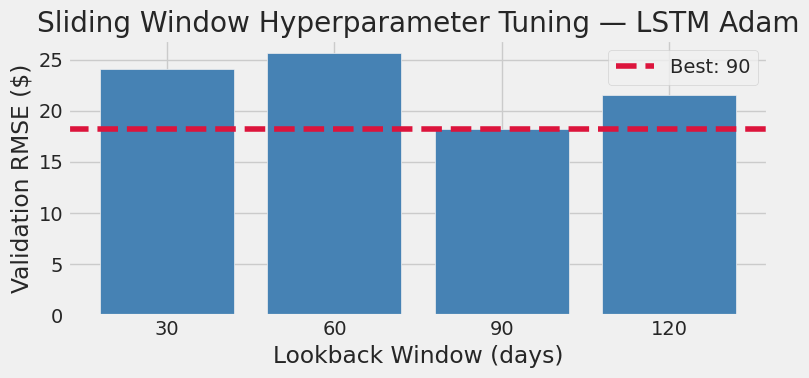

In [10]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_lstm_adam, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_lstm_adam, color='crimson', linestyle='--', label=f'Best: {best_window_size_lstm_adam}')
plt.title('Sliding Window Hyperparameter Tuning — LSTM Adam')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()


### GRU Adam Window Tuning

In [11]:
window_tuning_results_gru_adam = []
best_window_size_gru_adam = WINDOW_CANDIDATES[0]
best_window_val_rmse_gru_adam = float('inf')


In [12]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        GRU(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions)
    window_tuning_results_gru_adam.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_gru_adam:
        best_window_val_rmse_gru_adam = candidate_val_rmse
        best_window_size_gru_adam = candidate_window

print(f'\nSelected sliding window: {best_window_size_gru_adam} (validation RMSE: {best_window_val_rmse_gru_adam:.4f})')

x_train_gru_adam, y_train_gru_adam = create_sequences(full_scaled_data, best_window_size_gru_adam, 0, train_end)
x_val_gru_adam, y_val_gru_adam = create_sequences(full_scaled_data, best_window_size_gru_adam, train_end, val_end)
x_test_gru_adam, y_test_gru_adam = create_sequences(full_scaled_data, best_window_size_gru_adam, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_gru_adam)}, Val samples: {len(x_val_gru_adam)}, Test samples: {len(x_test_gru_adam)}')


Tuning sliding window on validation RMSE...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 22.5330


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 15.9008


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 19.8636


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 20.0897

Selected sliding window: 60 (validation RMSE: 15.9008)
Data preparation completed.
Train samples: 1804, Val samples: 339, Test samples: 339


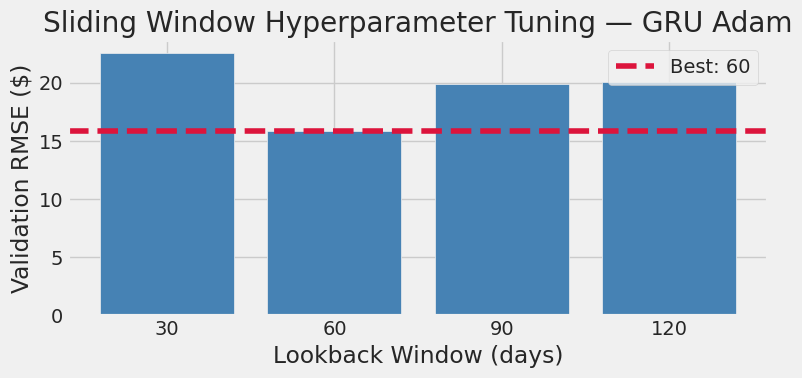

In [13]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_gru_adam, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_gru_adam, color='crimson', linestyle='--', label=f'Best: {best_window_size_gru_adam}')
plt.title('Sliding Window Hyperparameter Tuning — GRU Adam')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()


### LSTM NAG Window Tuning

In [14]:
window_tuning_results_lstm_nag = []
best_window_size_lstm_nag = WINDOW_CANDIDATES[0]
best_window_val_rmse_lstm_nag = float('inf')


In [15]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions)
    window_tuning_results_lstm_nag.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_lstm_nag:
        best_window_val_rmse_lstm_nag = candidate_val_rmse
        best_window_size_lstm_nag = candidate_window

print(f'\nSelected sliding window: {best_window_size_lstm_nag} (validation RMSE: {best_window_val_rmse_lstm_nag:.4f})')

x_train_lstm_nag, y_train_lstm_nag = create_sequences(full_scaled_data, best_window_size_lstm_nag, 0, train_end)
x_val_lstm_nag, y_val_lstm_nag = create_sequences(full_scaled_data, best_window_size_lstm_nag, train_end, val_end)
x_test_lstm_nag, y_test_lstm_nag = create_sequences(full_scaled_data, best_window_size_lstm_nag, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_lstm_nag)}, Val samples: {len(x_val_lstm_nag)}, Test samples: {len(x_test_lstm_nag)}')


Tuning sliding window on validation RMSE...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 13.1077


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 9.9270


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 12.3038


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 9.6306

Selected sliding window: 120 (validation RMSE: 9.6306)
Data preparation completed.
Train samples: 1744, Val samples: 279, Test samples: 279


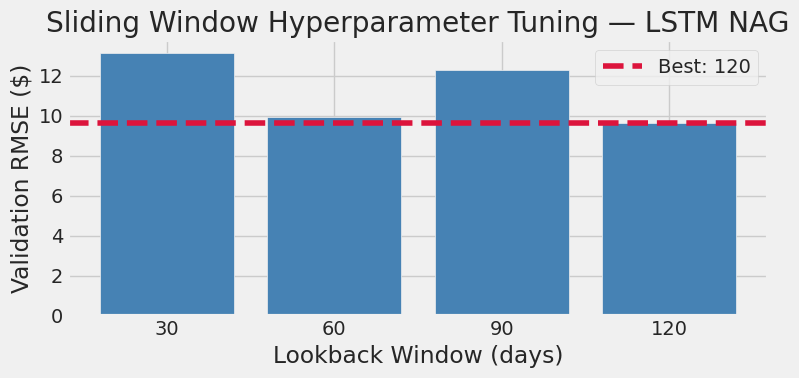

In [16]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_lstm_nag, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_lstm_nag, color='crimson', linestyle='--', label=f'Best: {best_window_size_lstm_nag}')
plt.title('Sliding Window Hyperparameter Tuning — LSTM NAG')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()


### GRU NAG Window Tuning

In [17]:
window_tuning_results_gru_nag = []
best_window_size_gru_nag = WINDOW_CANDIDATES[0]
best_window_val_rmse_gru_nag = float('inf')


In [18]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        GRU(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions)
    window_tuning_results_gru_nag.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_gru_nag:
        best_window_val_rmse_gru_nag = candidate_val_rmse
        best_window_size_gru_nag = candidate_window

print(f'\nSelected sliding window: {best_window_size_gru_nag} (validation RMSE: {best_window_val_rmse_gru_nag:.4f})')

x_train_gru_nag, y_train_gru_nag = create_sequences(full_scaled_data, best_window_size_gru_nag, 0, train_end)
x_val_gru_nag, y_val_gru_nag = create_sequences(full_scaled_data, best_window_size_gru_nag, train_end, val_end)
x_test_gru_nag, y_test_gru_nag = create_sequences(full_scaled_data, best_window_size_gru_nag, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_gru_nag)}, Val samples: {len(x_val_gru_nag)}, Test samples: {len(x_test_gru_nag)}')


Tuning sliding window on validation RMSE...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 5.7694


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 6.5303


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 6.8072


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 7.7190

Selected sliding window: 30 (validation RMSE: 5.7694)
Data preparation completed.
Train samples: 1834, Val samples: 369, Test samples: 369


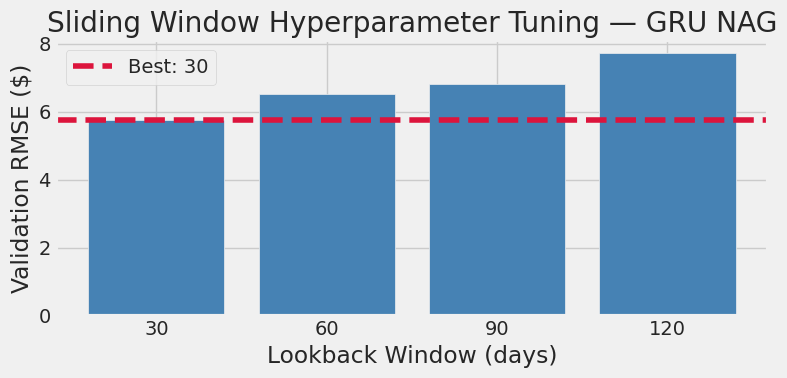

In [19]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_gru_nag, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_gru_nag, color='crimson', linestyle='--', label=f'Best: {best_window_size_gru_nag}')
plt.title('Sliding Window Hyperparameter Tuning — GRU NAG')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3: Building the LSTM and GRU Models


In [20]:
# Function to build the model
def build_model(model_type, optimizer, window_size):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
        model.add(Dropout(0.2))
        model.add(LSTM(32, return_sequences=False))
        model.add(Dropout(0.2))
    elif model_type == 'GRU':
        model.add(GRU(64, return_sequences=True, input_shape=(window_size, 1)))
        model.add(Dropout(0.2))
        model.add(GRU(32, return_sequences=False))
        model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

print('Model building function defined.')


Model building function defined.


## Step 4: Training Models and Evaluating Performance


**Training LSTM with Adam**

In [21]:
# LSTM with Adam
optimizer_adam = Adam(learning_rate=0.001)
model_lstm_adam = build_model('LSTM', optimizer_adam, best_window_size_lstm_adam)
history_lstm_adam = model_lstm_adam.fit(
    x_train_lstm_adam, y_train_lstm_adam,
    validation_data=(x_val_lstm_adam, y_val_lstm_adam),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('LSTM with Adam training completed.')


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.0132 - val_loss: 0.0108
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0024 - val_loss: 0.0087
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0021 - val_loss: 0.0120
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0020 - val_loss: 0.0069
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0015 - val_loss: 0.0091
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0016 - val_loss: 0.0063
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0015 - val_loss: 0.0057
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0014 - val_loss: 0.0355
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0013 - val_loss: 0.0144
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0011 - val_loss: 0.0093
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0010 - val_l

**Training LSTM with Nesterov (NAG)**


In [22]:
# LSTM with Nesterov
optimizer_nag = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_lstm_nag = build_model('LSTM', optimizer_nag, best_window_size_lstm_nag)
history_lstm_nag = model_lstm_nag.fit(
    x_train_lstm_nag, y_train_lstm_nag,
    validation_data=(x_val_lstm_nag, y_val_lstm_nag),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('LSTM with Nesterov training completed.')


Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0376 - val_loss: 0.0304
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0026 - val_loss: 0.0166
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0022 - val_loss: 0.0141
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0021 - val_loss: 0.0177
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0022 - val_loss: 0.0150
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0016 - val_loss: 0.0101
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0017 - val_loss: 0.0114
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0015 - val_loss: 0.0107
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0016 - val_loss: 0.0109
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0016 - val_loss: 0.0127
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0012 - val_loss: 0.0095
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0

**Training GRU with Adam**


In [23]:
# GRU with Adam
optimizer_adam_gru = Adam(learning_rate=0.001)
model_gru_adam = build_model('GRU', optimizer_adam_gru, best_window_size_gru_adam)
history_gru_adam = model_gru_adam.fit(
    x_train_gru_adam, y_train_gru_adam,
    validation_data=(x_val_gru_adam, y_val_gru_adam),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('GRU with Adam training completed.')


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.0239 - val_loss: 0.0019
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0017 - val_loss: 0.0038
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0016 - val_loss: 0.0055
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0012 - val_loss: 0.0076
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0010 - val_loss: 0.0114
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 8.9890e-04 - val_loss: 0.0070
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0011 - val_loss: 0.0072
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss:

**Training GRU with Nesterov (NAG)**


In [24]:
# GRU with Nesterov
optimizer_nag_gru = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_gru_nag = build_model('GRU', optimizer_nag_gru, best_window_size_gru_nag)
history_gru_nag = model_gru_nag.fit(
    x_train_gru_nag, y_train_gru_nag,
    validation_data=(x_val_gru_nag, y_val_gru_nag),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('GRU with Nesterov training completed.')


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0272 - val_loss: 0.0017
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0021 - val_loss: 0.0045
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0021 - val_loss: 0.0026
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0020 - val_loss: 0.0029
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0016 - val_loss: 0.0035
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0019 - val_loss: 0.0031
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0016 - val_loss: 0.0037
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0

## Step 4: Making Predictions and Evaluating Models


In [25]:
# Makes predictions with each model
def make_predictions(model, x_data):
    predictions = model.predict(x_data, verbose=0)
    return scaler.inverse_transform(predictions)


y_test_actual_lstm_adam = scaler.inverse_transform(y_test_lstm_adam.reshape(-1, 1))
y_test_actual_lstm_nag = scaler.inverse_transform(y_test_lstm_nag.reshape(-1, 1))
y_test_actual_gru_adam = scaler.inverse_transform(y_test_gru_adam.reshape(-1, 1))
y_test_actual_gru_nag = scaler.inverse_transform(y_test_gru_nag.reshape(-1, 1))

pred_lstm_adam = make_predictions(model_lstm_adam, x_test_lstm_adam)
pred_lstm_nag = make_predictions(model_lstm_nag, x_test_lstm_nag)
pred_gru_adam = make_predictions(model_gru_adam, x_test_gru_adam)
pred_gru_nag = make_predictions(model_gru_nag, x_test_gru_nag)

# Metrics in original price scale
rmse_lstm_adam = np.sqrt(mean_squared_error(y_test_actual_lstm_adam, pred_lstm_adam))
rmse_lstm_nag = np.sqrt(mean_squared_error(y_test_actual_lstm_nag, pred_lstm_nag))
rmse_gru_adam = np.sqrt(mean_squared_error(y_test_actual_gru_adam, pred_gru_adam))
rmse_gru_nag = np.sqrt(mean_squared_error(y_test_actual_gru_nag, pred_gru_nag))

mae_lstm_adam = mean_absolute_error(y_test_actual_lstm_adam, pred_lstm_adam)
mae_lstm_nag = mean_absolute_error(y_test_actual_lstm_nag, pred_lstm_nag)
mae_gru_adam = mean_absolute_error(y_test_actual_gru_adam, pred_gru_adam)
mae_gru_nag = mean_absolute_error(y_test_actual_gru_nag, pred_gru_nag)

r2_lstm_adam = r2_score(y_test_actual_lstm_adam, pred_lstm_adam)
r2_lstm_nag = r2_score(y_test_actual_lstm_nag, pred_lstm_nag)
r2_gru_adam = r2_score(y_test_actual_gru_adam, pred_gru_adam)
r2_gru_nag = r2_score(y_test_actual_gru_nag, pred_gru_nag)

metrics_values = {
    'LSTM Adam': {'RMSE': rmse_lstm_adam, 'MAE': mae_lstm_adam, 'R2': r2_lstm_adam},
    'LSTM NAG':  {'RMSE': rmse_lstm_nag,  'MAE': mae_lstm_nag,  'R2': r2_lstm_nag},
    'GRU Adam':  {'RMSE': rmse_gru_adam,  'MAE': mae_gru_adam,  'R2': r2_gru_adam},
    'GRU NAG':   {'RMSE': rmse_gru_nag,   'MAE': mae_gru_nag,   'R2': r2_gru_nag},
}

# Keep rmse_values for any later cells that still expect it
rmse_values = {name: m['RMSE'] for name, m in metrics_values.items()}

print('Predictions and metric calculations completed.')
for model_name, m in metrics_values.items():
    print(f"  {model_name}: RMSE = {m['RMSE']:.4f} | MAE = {m['MAE']:.4f} | R^2 = {m['R2']:.4f}")

Predictions and metric calculations completed.
  LSTM Adam: RMSE = 23.4734 | MAE = 22.8194 | R^2 = -1.5720
  LSTM NAG: RMSE = 24.0611 | MAE = 22.0872 | R^2 = -1.5750
  GRU Adam: RMSE = 18.0387 | MAE = 17.5436 | R^2 = -0.3901
  GRU NAG: RMSE = 13.9353 | MAE = 12.8611 | R^2 = 0.3419


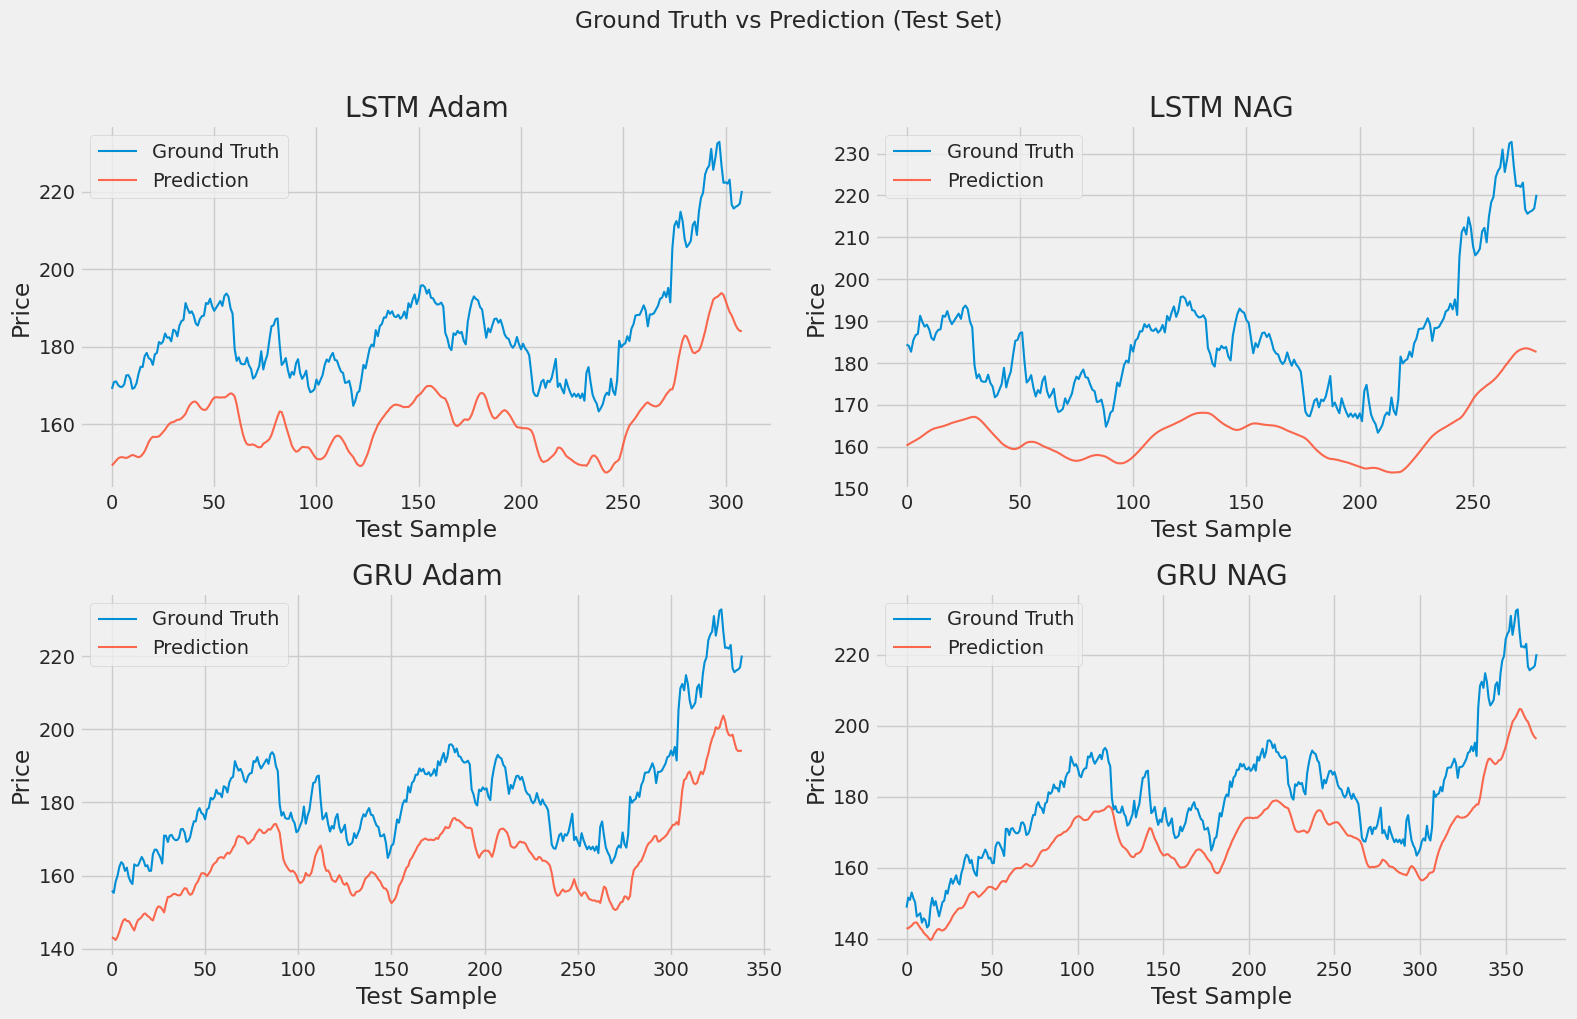

In [26]:
# Ground truth vs prediction for every model
prediction_plots = [
    ('LSTM Adam', y_test_actual_lstm_adam, pred_lstm_adam),
    ('LSTM NAG',  y_test_actual_lstm_nag,  pred_lstm_nag),
    ('GRU Adam',  y_test_actual_gru_adam,  pred_gru_adam),
    ('GRU NAG',   y_test_actual_gru_nag,   pred_gru_nag),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

for ax, (name, y_true, y_pred) in zip(axes, prediction_plots):
    ax.plot(y_true, label='Ground Truth', linewidth=1.5)
    ax.plot(y_pred, label='Prediction', linewidth=1.5, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Price')
    ax.legend()

plt.suptitle('Ground Truth vs Prediction (Test Set)', y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Visualizations and Analysis
Visualizations included are:
* Line Plot of Loss vs. Epochs
* Line Plot of Log(Loss) vs. Epochs
* Bar chart of Final loss by Model-Optimizer Combination
* RMSE Summary table
* Training and Validation Loss Heatmaps



**Line Plot of Loss vs. Epochs**

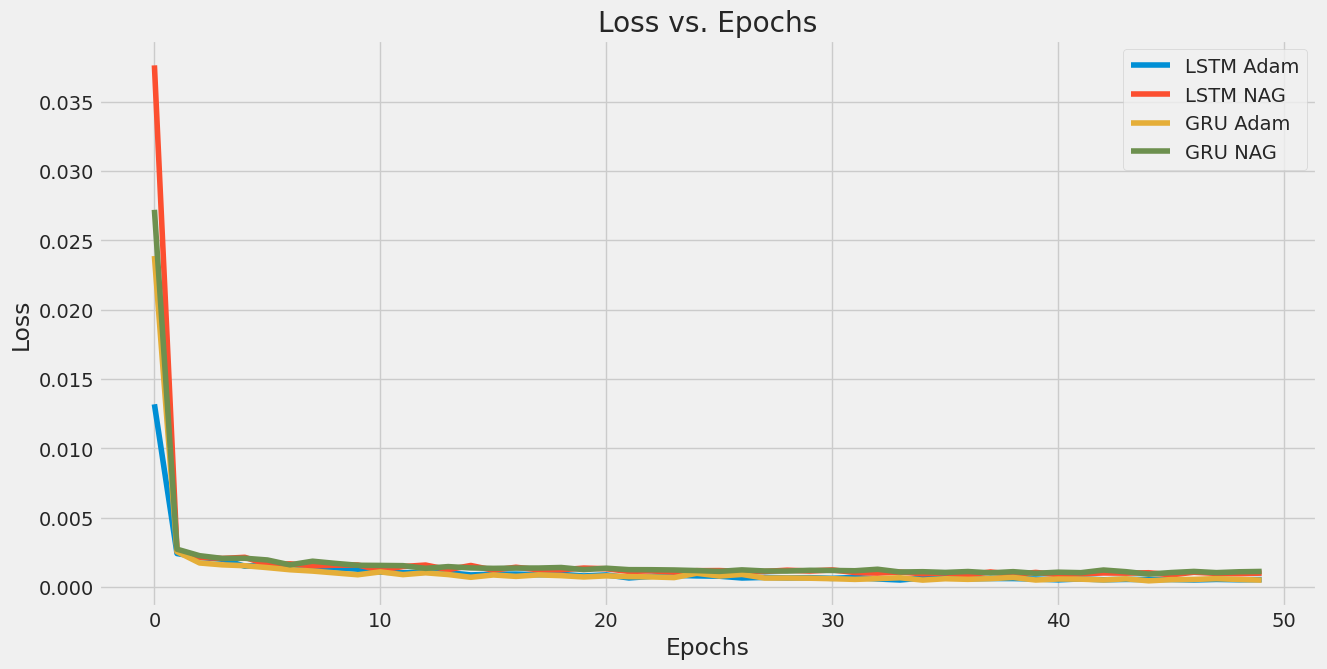

Loss vs. Epochs plot generated.


In [27]:
# Line Plot of Loss vs. Epochs
plt.figure(figsize=(14, 7))
plt.plot(history_lstm_adam.history['loss'], label='LSTM Adam')
plt.plot(history_lstm_nag.history['loss'], label='LSTM NAG')
plt.plot(history_gru_adam.history['loss'], label='GRU Adam')
plt.plot(history_gru_nag.history['loss'], label='GRU NAG')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("Loss vs. Epochs plot generated.")


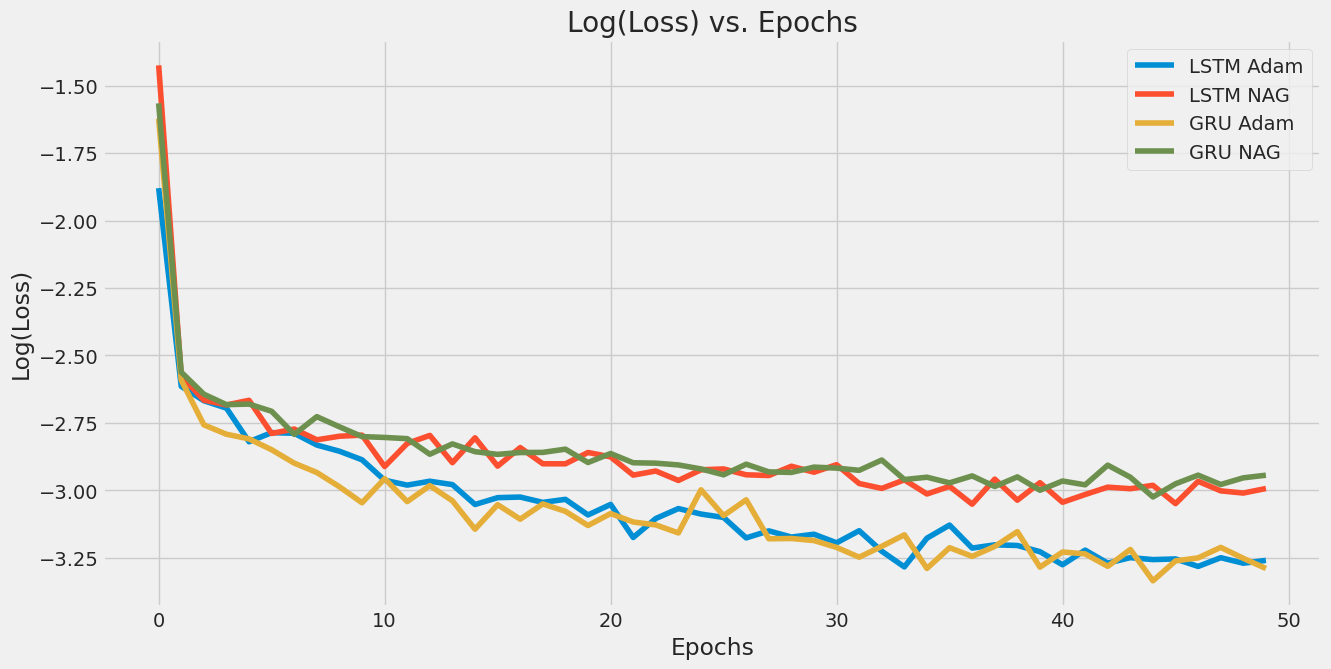

Convergence curves generated.


In [28]:
# Convergence Curves
plt.figure(figsize=(14, 7))
plt.plot(np.log10(history_lstm_adam.history['loss']), label='LSTM Adam')
plt.plot(np.log10(history_lstm_nag.history['loss']), label='LSTM NAG')
plt.plot(np.log10(history_gru_adam.history['loss']), label='GRU Adam')
plt.plot(np.log10(history_gru_nag.history['loss']), label='GRU NAG')
plt.title('Log(Loss) vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Log(Loss)')
plt.legend()
plt.show()

print("Convergence curves generated.")


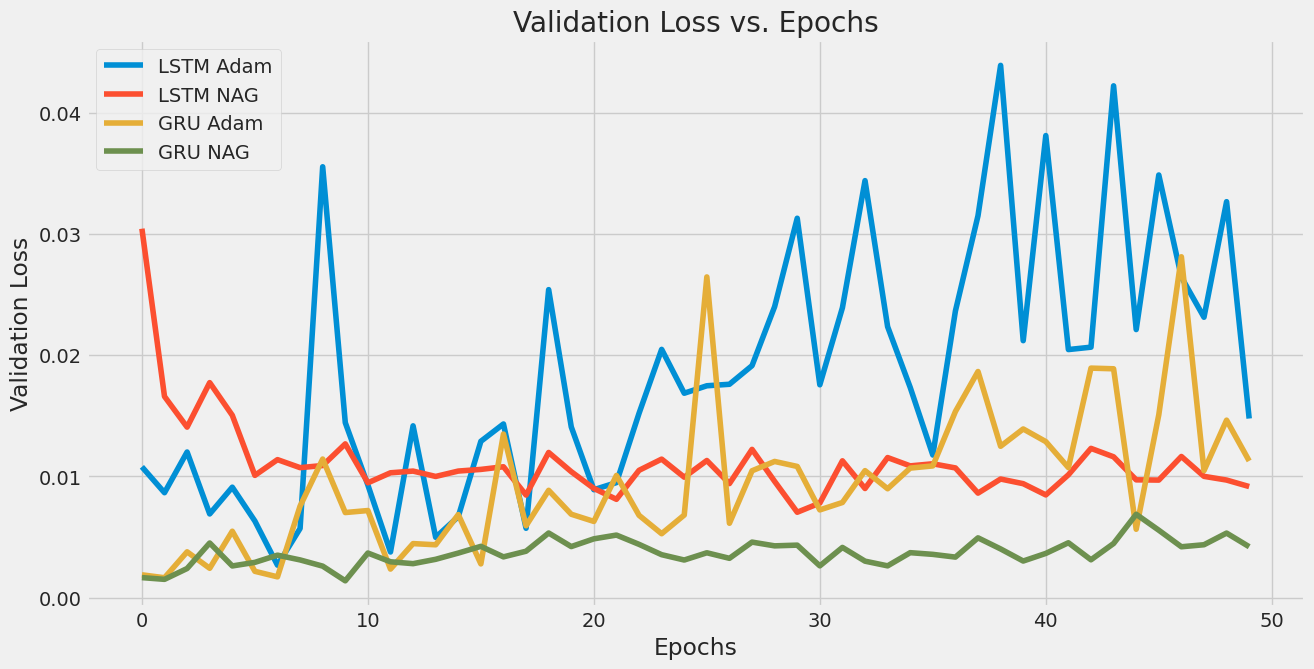

Validation Loss vs. Epochs plot generated.


In [29]:
# Line Plot of Validation Loss vs. Epochs
plt.figure(figsize=(14, 7))
plt.plot(history_lstm_adam.history['val_loss'], label='LSTM Adam')
plt.plot(history_lstm_nag.history['val_loss'], label='LSTM NAG')
plt.plot(history_gru_adam.history['val_loss'], label='GRU Adam')
plt.plot(history_gru_nag.history['val_loss'], label='GRU NAG')
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

print("Validation Loss vs. Epochs plot generated.")

**Bar Charts of Final Loss**

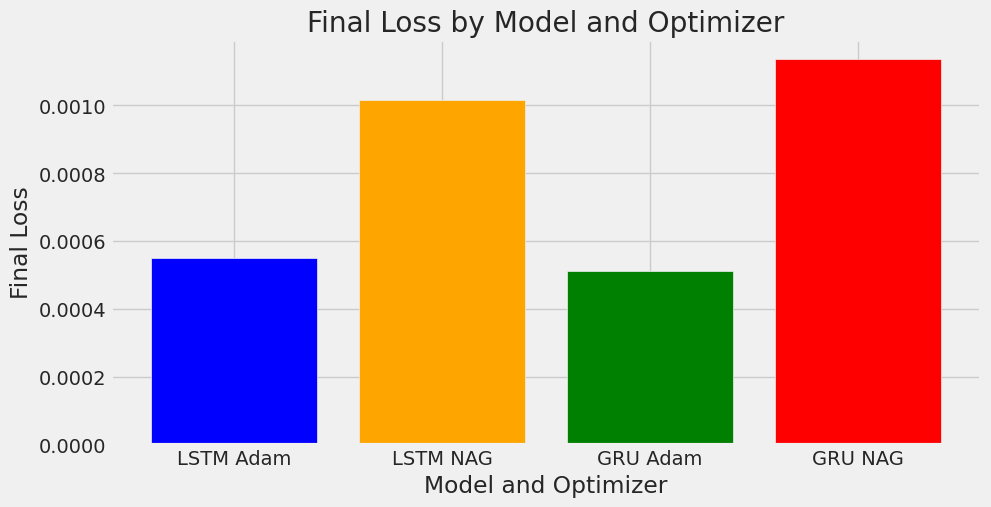

Final Loss bar chart generated.


In [30]:
# Bar Chart of Final Loss
final_losses = [
    history_lstm_adam.history['loss'][-1],
    history_lstm_nag.history['loss'][-1],
    history_gru_adam.history['loss'][-1],
    history_gru_nag.history['loss'][-1]
]

models = ['LSTM Adam', 'LSTM NAG', 'GRU Adam', 'GRU NAG']

plt.figure(figsize=(10, 5))
plt.bar(models, final_losses, color=['blue', 'orange', 'green', 'red'])
plt.title('Final Loss by Model and Optimizer')
plt.xlabel('Model and Optimizer')
plt.ylabel('Final Loss')
plt.show()

print("Final Loss bar chart generated.")


**Metrics Summary Table**

In [31]:
# Metrics Summary Table
metrics_table = [
    [model, f"{m['RMSE']:.4f}", f"{m['MAE']:.4f}", f"{m['R2']:.4f}"]
    for model, m in metrics_values.items()
]
print(tabulate(
    metrics_table,
    headers=['Model & Optimizer', 'RMSE', 'MAE', 'R^2'],
    tablefmt='pretty'
))

print("Metrics summary table generated.")

+-------------------+---------+---------+---------+
| Model & Optimizer |  RMSE   |   MAE   |   R^2   |
+-------------------+---------+---------+---------+
|     LSTM Adam     | 23.4734 | 22.8194 | -1.5720 |
|     LSTM NAG      | 24.0611 | 22.0872 | -1.5750 |
|     GRU Adam      | 18.0387 | 17.5436 | -0.3901 |
|      GRU NAG      | 13.9353 | 12.8611 | 0.3419  |
+-------------------+---------+---------+---------+
Metrics summary table generated.


**Heatmaps for summary**


In [32]:
# Extract loss and validation loss values automatically from training history
lstm_adam_loss = history_lstm_adam.history['loss']
lstm_adam_val_loss = history_lstm_adam.history['val_loss']

lstm_nag_loss = history_lstm_nag.history['loss']
lstm_nag_val_loss = history_lstm_nag.history['val_loss']

gru_adam_loss = history_gru_adam.history['loss']
gru_adam_val_loss = history_gru_adam.history['val_loss']

gru_nag_loss = history_gru_nag.history['loss']
gru_nag_val_loss = history_gru_nag.history['val_loss']


In [33]:
# Convert lists into a DataFrame (variable epoch count due to early stopping)
max_epoch_count = max(
    len(history_lstm_adam.history['loss']),
    len(history_lstm_nag.history['loss']),
    len(history_gru_adam.history['loss']),
    len(history_gru_nag.history['loss'])
)
epochs = np.arange(1, max_epoch_count + 1)
data = {
    'Epoch': epochs,
    'LSTM Adam Loss': lstm_adam_loss + [np.nan] * (max_epoch_count - len(lstm_adam_loss)),
    'LSTM NAG Loss': lstm_nag_loss + [np.nan] * (max_epoch_count - len(lstm_nag_loss)),
    'GRU Adam Loss': gru_adam_loss + [np.nan] * (max_epoch_count - len(gru_adam_loss)),
    'GRU NAG Loss': gru_nag_loss + [np.nan] * (max_epoch_count - len(gru_nag_loss)),
    'LSTM Adam Val Loss': lstm_adam_val_loss + [np.nan] * (max_epoch_count - len(lstm_adam_val_loss)),
    'LSTM NAG Val Loss': lstm_nag_val_loss + [np.nan] * (max_epoch_count - len(lstm_nag_val_loss)),
    'GRU Adam Val Loss': gru_adam_val_loss + [np.nan] * (max_epoch_count - len(gru_adam_val_loss)),
    'GRU NAG Val Loss': gru_nag_val_loss + [np.nan] * (max_epoch_count - len(gru_nag_val_loss)),
}
df_losses = pd.DataFrame(data)
df_losses


,Epoch,LSTM Adam Loss,LSTM NAG Loss,GRU Adam Loss,GRU NAG Loss,LSTM Adam Val Loss,LSTM NAG Val Loss,GRU Adam Val Loss,GRU NAG Val Loss
0,1,0.013187,0.037618,0.023876,0.027205,0.010792,0.030430,0.001886,0.001656
1,2,0.002429,0.002648,0.002560,0.002741,0.008658,0.016596,0.001645,0.001513
2,3,0.002148,0.002159,0.001748,0.002271,0.012015,0.014067,0.003783,0.002407
3,4,0.002016,0.002072,0.001613,0.002077,0.006906,0.017736,0.002424,0.004511
4,5,0.001513,0.002156,0.001551,0.002087,0.009113,0.015041,0.005482,0.002617
5,6,0.001636,0.001624,0.001413,0.001963,0.006319,0.010088,0.002175,0.002913
6,7,0.001627,0.001687,0.001261,0.001612,0.002681,0.011386,0.001719,0.003508
7,8,0.001471,0.001539,0.001164,0.001875,0.005710,0.010724,0.007553,0.003115
8,9,0.001396,0.001586,0.001030,0.001719,0.035536,0.010900,0.011435,0.002603
9,10,0.001297,0.001601,0.000899,0.001582,0.014436,0.012685,0.007022,0.001392


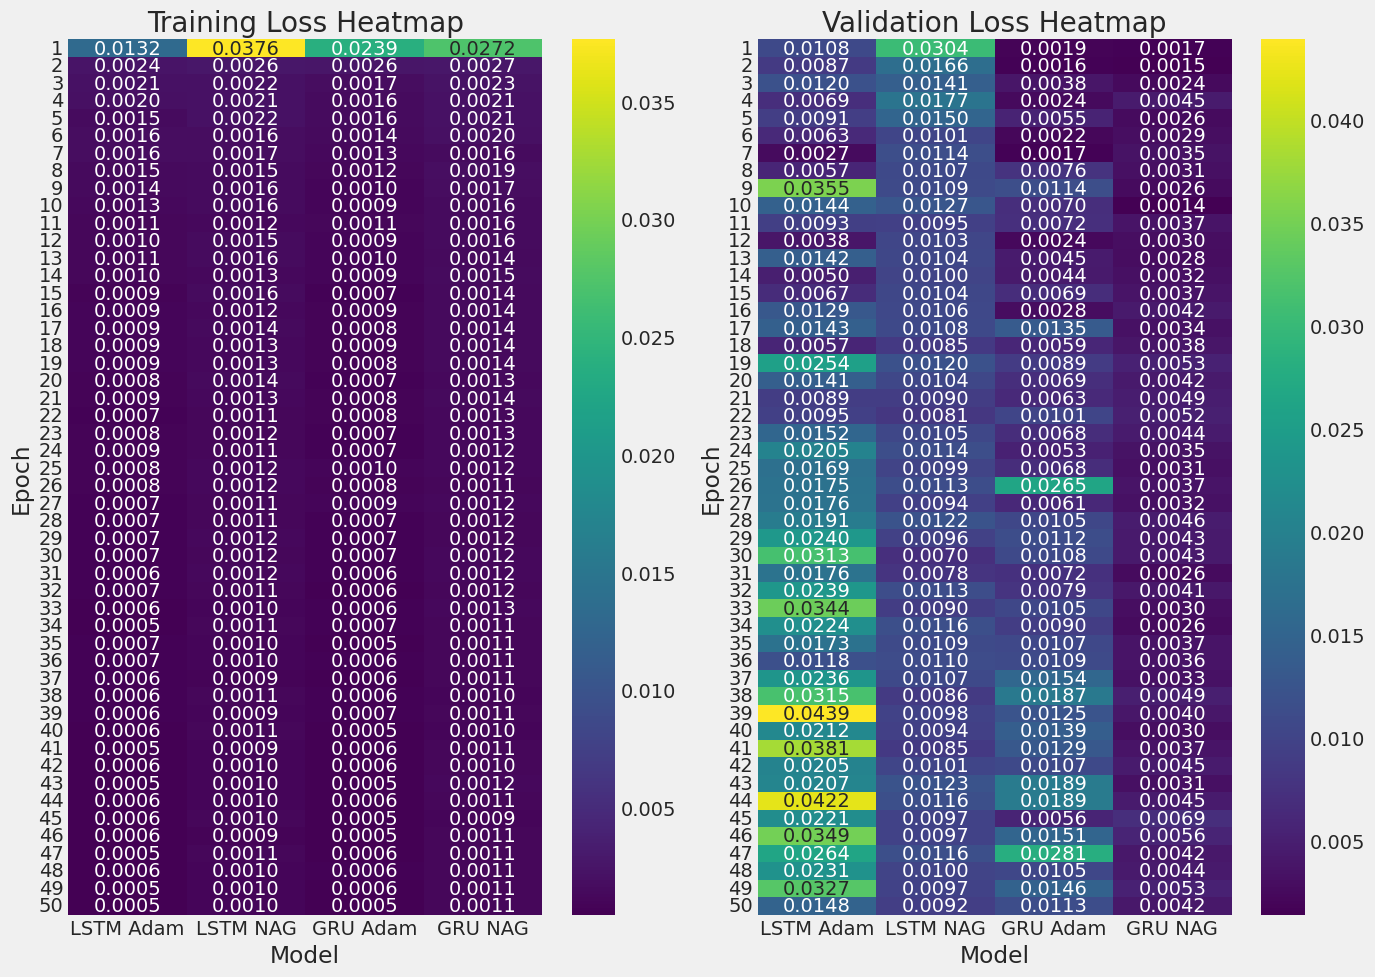

In [34]:
# Create heatmaps for loss values
plt.figure(figsize=(14, 10))

loss_cols = ['LSTM Adam Loss', 'LSTM NAG Loss', 'GRU Adam Loss', 'GRU NAG Loss']
val_cols = ['LSTM Adam Val Loss', 'LSTM NAG Val Loss', 'GRU Adam Val Loss', 'GRU NAG Val Loss']
epoch_labels = df_losses['Epoch'].astype(int).tolist()

plt.subplot(1, 2, 1)
sns.heatmap(
    df_losses[loss_cols].values,
    annot=True, cmap='viridis', fmt='.4f',
    xticklabels=['LSTM Adam', 'LSTM NAG', 'GRU Adam', 'GRU NAG'],
    yticklabels=epoch_labels
)
plt.title('Training Loss Heatmap')
plt.xlabel('Model')
plt.ylabel('Epoch')

plt.subplot(1, 2, 2)
sns.heatmap(
    df_losses[val_cols].values,
    annot=True, cmap='viridis', fmt='.4f',
    xticklabels=['LSTM Adam', 'LSTM NAG', 'GRU Adam', 'GRU NAG'],
    yticklabels=epoch_labels
)
plt.title('Validation Loss Heatmap')
plt.xlabel('Model')
plt.ylabel('Epoch')

plt.tight_layout()
plt.show()


**Training Loss Histogram**

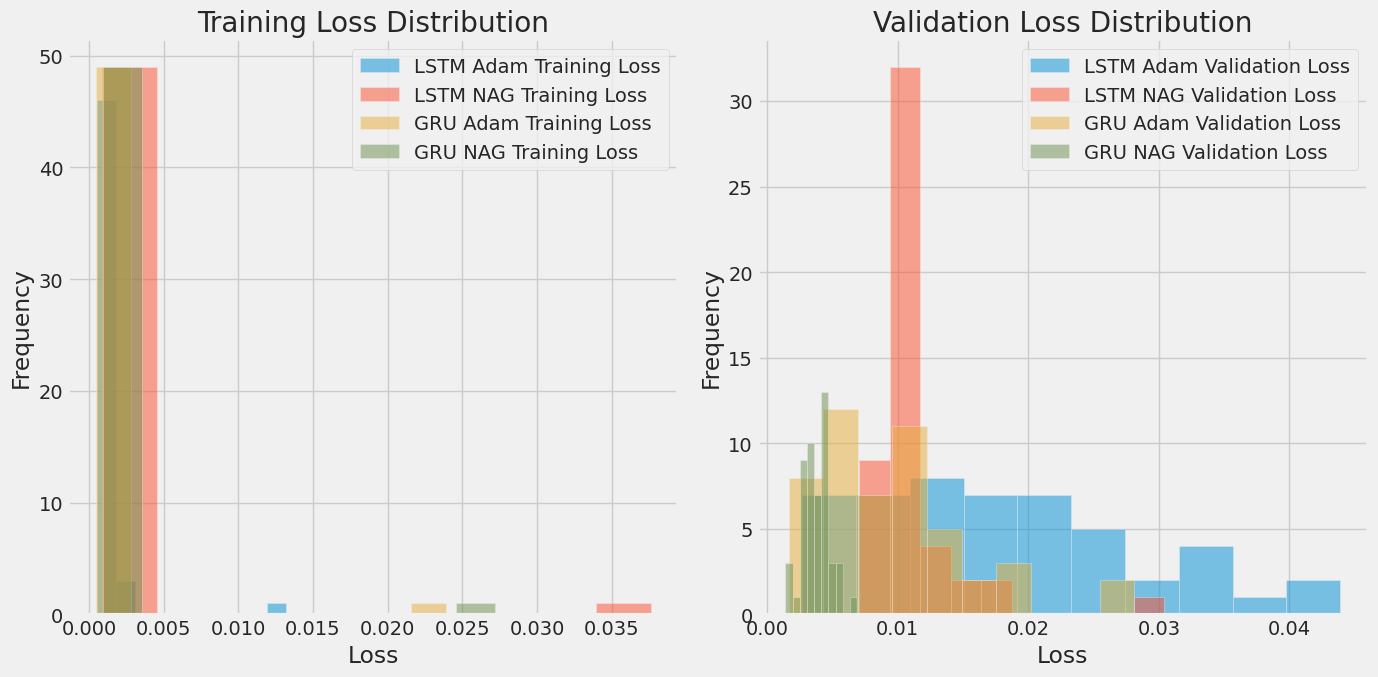

In [35]:
plt.figure(figsize=(14, 7))

# Training loss histogram
plt.subplot(1, 2, 1)
plt.hist(lstm_adam_loss, bins=10, alpha=0.5, label='LSTM Adam Training Loss')
plt.hist(lstm_nag_loss, bins=10, alpha=0.5, label='LSTM NAG Training Loss')
plt.hist(gru_adam_loss, bins=10, alpha=0.5, label='GRU Adam Training Loss')
plt.hist(gru_nag_loss, bins=10, alpha=0.5, label='GRU NAG Training Loss')
plt.title('Training Loss Distribution')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()

# Validation loss histogram
plt.subplot(1, 2, 2)
plt.hist(lstm_adam_val_loss, bins=10, alpha=0.5, label='LSTM Adam Validation Loss')
plt.hist(lstm_nag_val_loss, bins=10, alpha=0.5, label='LSTM NAG Validation Loss')
plt.hist(gru_adam_val_loss, bins=10, alpha=0.5, label='GRU Adam Validation Loss')
plt.hist(gru_nag_val_loss, bins=10, alpha=0.5, label='GRU NAG Validation Loss')
plt.title('Validation Loss Distribution')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()
